# 🏠 House Price Prediction with XGBoost
### California Housing Dataset

This notebook walks through a complete ML pipeline:
1. Load & Explore Data
2. Preprocessing & Feature Engineering
3. Train/Test Split
4. Train XGBoost Model
5. Evaluate & Visualize Results
6. Hyperparameter Tuning
7. Feature Importance

## 📦 Cell 1 — Install & Import Libraries

In [42]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All libraries imported successfully!')
print(f'   XGBoost version: {xgb.__version__}')

✅ All libraries imported successfully!
   XGBoost version: 3.2.0


## 📂 Cell 2 — Load Dataset
> Upload `housing.csv` to your Colab session or mount Google Drive.

In [43]:

df = pd.read_csv('housing.csv')

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 20,640 rows × 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 🔍 Cell 3 — Exploratory Data Analysis (EDA)

In [44]:
# Basic info
print('=== Dataset Info ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

=== Missing Values ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


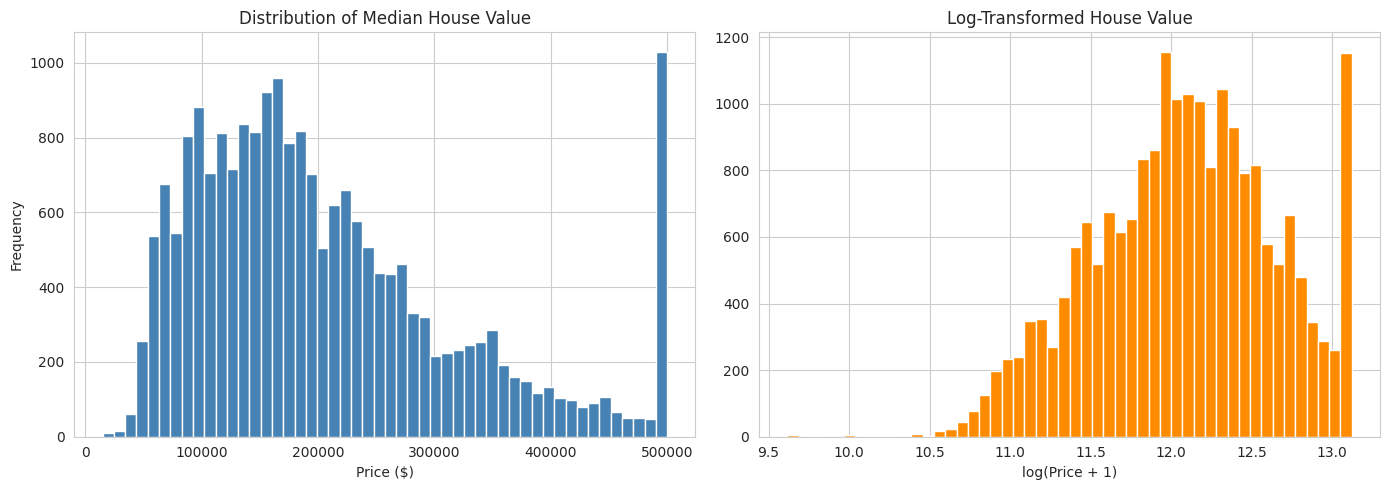

In [45]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['median_house_value']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed House Value')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

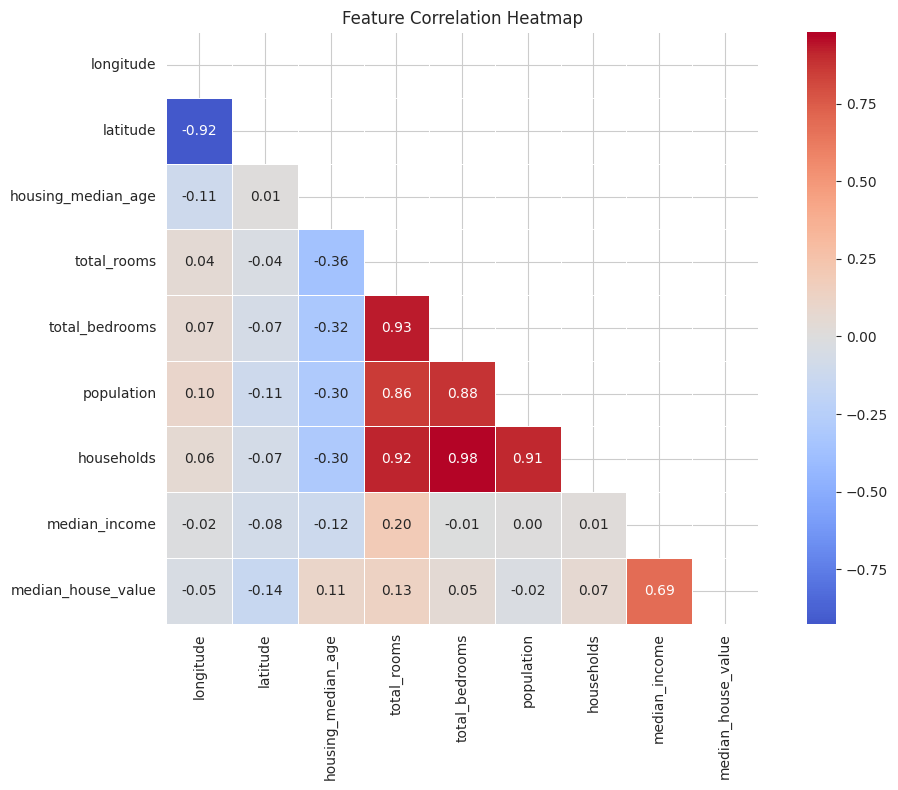

In [46]:
# Correlation heatmap (numerical features)
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

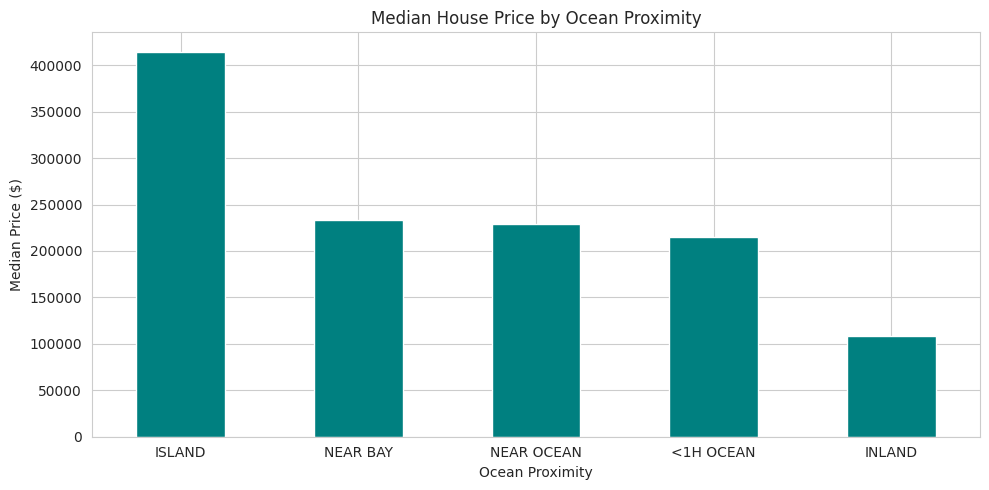

In [47]:
# House price by ocean proximity
plt.figure(figsize=(10, 5))
df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).plot(
    kind='bar', color='teal', edgecolor='white', rot=0
)
plt.title('Median House Price by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median Price ($)')
plt.tight_layout()
plt.show()

## 🛠️ Cell 4 — Preprocessing & Feature Engineering

In [48]:
df_clean = df.copy()

# ── 1. Handle missing values ───────────────────────────────────────────────
df_clean['total_bedrooms'].fillna(df_clean['total_bedrooms'].median(), inplace=True)

# ── 2. Encode categorical feature ─────────────────────────────────────────
df_clean = pd.get_dummies(df_clean, columns=['ocean_proximity'], drop_first=False)

# ── 3. Feature Engineering ────────────────────────────────────────────────
df_clean['rooms_per_household']    = df_clean['total_rooms']    / df_clean['households']
df_clean['bedrooms_per_room']      = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['population_per_household'] = df_clean['population']  / df_clean['households']
df_clean['income_per_room']        = df_clean['median_income'] / df_clean['total_rooms']
df_clean.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', str(col))
    for col in df_clean.columns]

print(f' Features after preprocessing: {df_clean.shape[1]} columns')
print('Columns:', list(df_clean.columns))

 Features after preprocessing: 18 columns
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity__1H_OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR_BAY', 'ocean_proximity_NEAR_OCEAN', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_room']


## ✂️ Cell 5 — Train / Test Split

In [49]:
TARGET = 'median_house_value'

X = df_clean.drop(columns=[TARGET])
y = np.log1p(df_clean[TARGET])   # log-transform target to reduce skewness

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size : {X_train.shape[0]:,} samples')
print(f'Test  size : {X_test.shape[0]:,} samples')
print(f'Features   : {X_train.shape[1]}')

Train size : 16,512 samples
Test  size : 4,128 samples
Features   : 17


## 🚀 Cell 6 — Train XGBoost Model (Baseline)

In [50]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train.values, y_train_log,
    eval_set=[(X_train.values, y_train_log), (X_test.values, y_test_log)],
    verbose=100
)

print('\n Training complete!')

[0]	validation_0-rmse:0.04222	validation_1-rmse:0.04234
[100]	validation_0-rmse:0.01613	validation_1-rmse:0.01813
[200]	validation_0-rmse:0.01428	validation_1-rmse:0.01729
[300]	validation_0-rmse:0.01315	validation_1-rmse:0.01695
[400]	validation_0-rmse:0.01230	validation_1-rmse:0.01671
[499]	validation_0-rmse:0.01162	validation_1-rmse:0.01659

 Training complete!


## 📊 Cell 7 — Evaluate Model

In [51]:
def evaluate(model, X, y, split_name='Test'):
    preds_log = model.predict(X)
    preds     = np.expm1(preds_log)   # reverse log transform
    actuals   = np.expm1(y)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    r2   = r2_score(actuals, preds)

    print(f'── {split_name} Metrics ──────────────────')
    print(f'  RMSE : ${rmse:,.0f}')
    print(f'  MAE  : ${mae:,.0f}')
    print(f'  R²   : {r2:.4f}')
    return preds, actuals

train_preds, train_actuals = evaluate(xgb_model, X_train, y_train, 'Train')
print()
test_preds,  test_actuals  = evaluate(xgb_model, X_test,  y_test,  'Test')

── Train Metrics ──────────────────
  RMSE : $237,260
  MAE  : $207,183
  R²   : -3.2110

── Test Metrics ──────────────────
  RMSE : $235,222
  MAE  : $205,488
  R²   : -3.2223


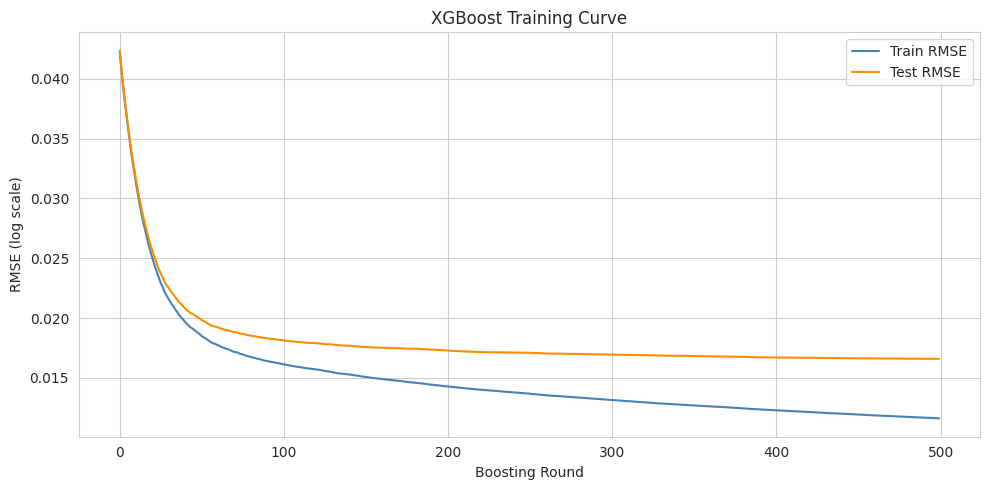

In [52]:
# Training curve (loss over boosting rounds)
results = xgb_model.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['rmse'], label='Train RMSE', color='steelblue')
plt.plot(results['validation_1']['rmse'], label='Test RMSE',  color='darkorange')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE (log scale)')
plt.title('XGBoost Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

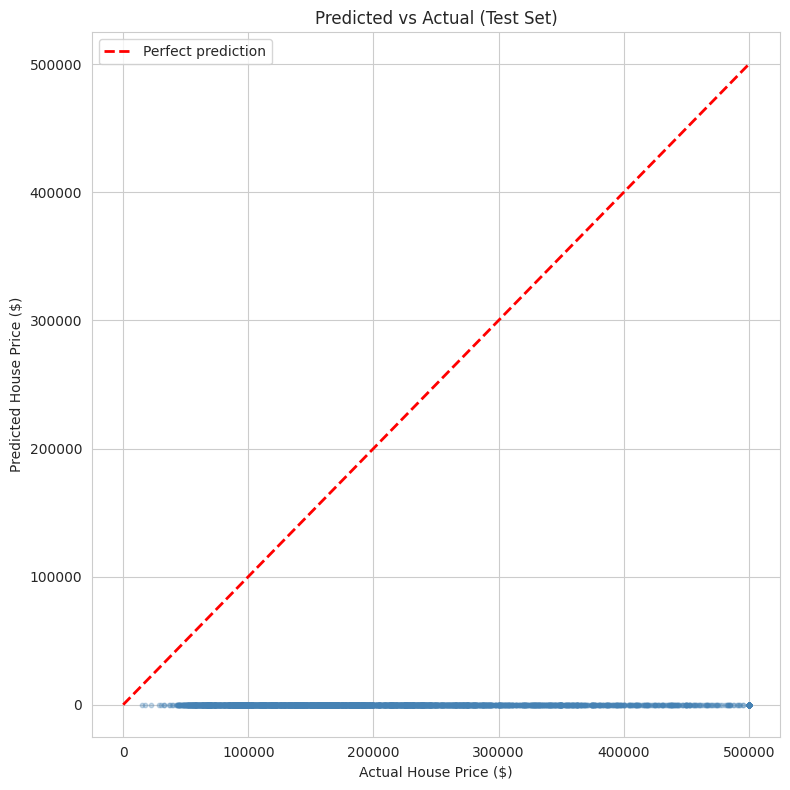

In [53]:
# Predicted vs Actual scatter
plt.figure(figsize=(8, 8))
plt.scatter(test_actuals, test_preds, alpha=0.3, color='steelblue', s=10)
max_val = max(test_actuals.max(), test_preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual House Price ($)')
plt.ylabel('Predicted House Price ($)')
plt.title('Predicted vs Actual (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

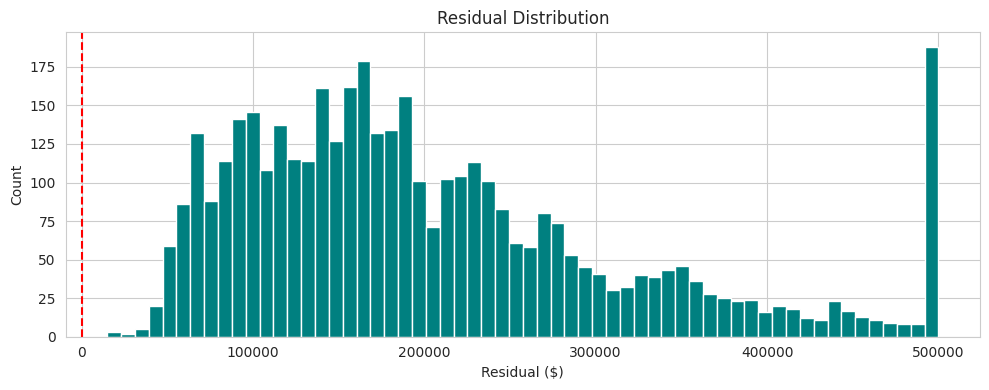

In [54]:
# Residuals distribution
residuals = test_actuals.values - test_preds

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=60, color='teal', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual ($)')
plt.ylabel('Count')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

## 🔎 Cell 8 — Feature Importance

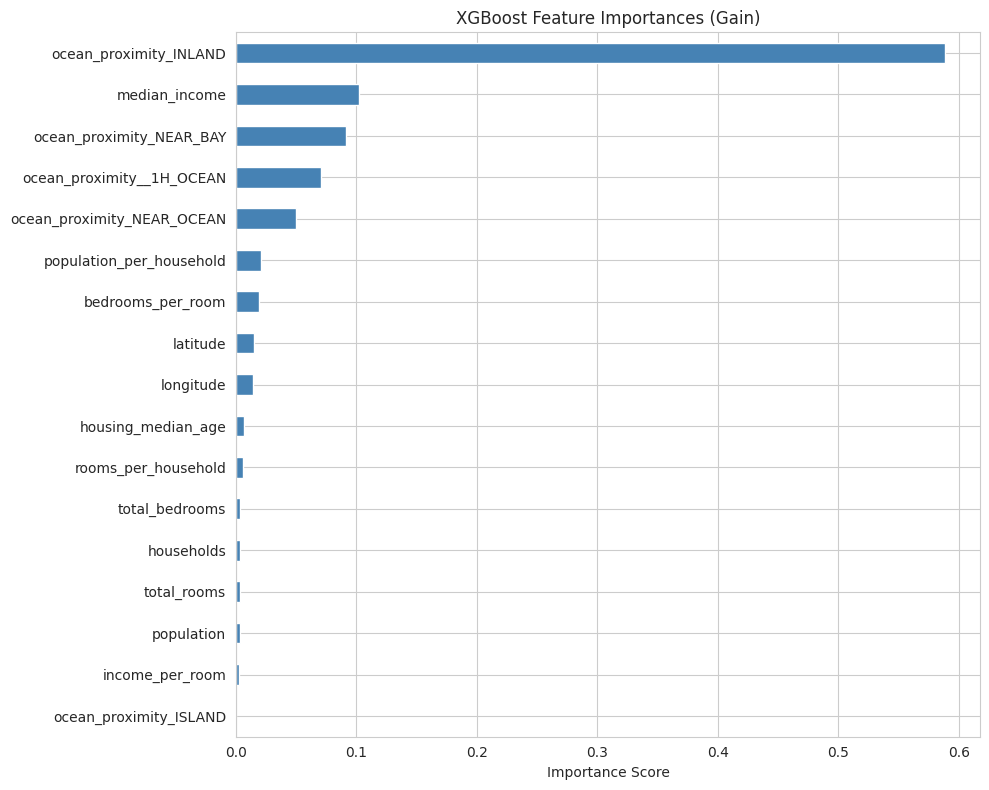

Top 5 features:
ocean_proximity_INLAND        0.588228
median_income                 0.102015
ocean_proximity_NEAR_BAY      0.091160
ocean_proximity__1H_OCEAN     0.070551
ocean_proximity_NEAR_OCEAN    0.050081
dtype: float32


In [55]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost Feature Importances (Gain)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(importances.sort_values(ascending=False).head())

## ⚙️ Cell 9 — Hyperparameter Tuning (RandomizedSearchCV)
> This cell may take a few minutes. Reduce `n_iter` for faster runs.

In [56]:
param_dist = {
    'n_estimators'     : [300, 500, 700],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.15],
    'max_depth'        : [4, 5, 6, 7, 8],
    'subsample'        : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9],
    'min_child_weight' : [1, 3, 5, 7],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5],
    'reg_lambda'       : [0.5, 1.0, 1.5, 2.0],
}

base_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1, eval_metric='rmse')

search = RandomizedSearchCV(
    base_xgb,
    param_distributions=param_dist,
    n_iter=10,              # increase for more thorough search
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print('\n✅ Best Parameters:')
for k, v in search.best_params_.items():
    print(f'   {k}: {v}')

print(f'\nBest CV RMSE (log scale): {-search.best_score_:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best Parameters:
   subsample: 0.8
   reg_lambda: 2.0
   reg_alpha: 0
   n_estimators: 700
   min_child_weight: 5
   max_depth: 8
   learning_rate: 0.05
   colsample_bytree: 0.8

Best CV RMSE (log scale): 0.2161


## 🏆 Cell 10 — Evaluate Best Tuned Model

In [57]:
best_model = search.best_estimator_

print('=== Tuned Model Evaluation ===')
print()
evaluate(best_model, X_train, y_train, 'Train')
print()
evaluate(best_model, X_test,  y_test,  'Test')

=== Tuned Model Evaluation ===

── Train Metrics ──────────────────
  RMSE : $16,367
  MAE  : $10,384
  R²   : 0.9800

── Test Metrics ──────────────────
  RMSE : $44,699
  MAE  : $27,972
  R²   : 0.8475


(array([ 51435.117,  82920.78 , 482177.7  , ..., 477454.94 ,  68436.26 ,
        168014.69 ], dtype=float32),
 20046     47700.0
 3024      45800.0
 15663    500001.0
 20484    218600.0
 9814     278000.0
            ...   
 15362    263300.0
 16623    266800.0
 18086    500001.0
 2144      72300.0
 3665     151500.0
 Name: median_house_value, Length: 4128, dtype: float64)

## 💾 Cell 11 — Save Model

In [58]:
import joblib

joblib.dump(best_model, 'xgboost_housing_model.pkl')
print('✅ Model saved as xgboost_housing_model.pkl')

# To reload later:
# loaded_model = joblib.load('xgboost_housing_model.pkl')

# Optional: also save in XGBoost native format
best_model.save_model('xgboost_housing_model.json')
print('✅ Model also saved as xgboost_housing_model.json')

✅ Model saved as xgboost_housing_model.pkl
✅ Model also saved as xgboost_housing_model.json


## 🔮 Cell 12 — Predict on New Data

In [59]:
# Example: predict a new house
# Make sure column order matches X_train.columns

sample = pd.DataFrame([{
    'longitude'                   : -122.23,
    'latitude'                    : 37.88,
    'housing_median_age'          : 41.0,
    'total_rooms'                 : 880.0,
    'total_bedrooms'              : 129.0,
    'population'                  : 322.0,
    'households'                  : 126.0,
    'median_income'               : 8.3252,
    'ocean_proximity_<1H OCEAN'   : 0,
    'ocean_proximity_INLAND'      : 0,
    'ocean_proximity_ISLAND'      : 0,
    'ocean_proximity_NEAR BAY'    : 1,
    'ocean_proximity_NEAR OCEAN'  : 0,
    'rooms_per_household'         : 880 / 126,
    'bedrooms_per_room'           : 129 / 880,
    'population_per_household'    : 322 / 126,
    'income_per_room'             : 8.3252 / 880,
}])

# Align columns with training data
sample = sample.reindex(columns=X_train.columns, fill_value=0)

pred_log = best_model.predict(sample)
pred_price = np.expm1(pred_log)[0]

print(f'🏠 Predicted House Price: ${pred_price:,.0f}')

🏠 Predicted House Price: $431,207
